# **TEMPLATE** <br>
 **Federated CNN Image Multiclassifier for Custom Dataset**


```
📌 Don't forget to create a COPY before experimenting wtih anything....
```



## **FedCNN Custom Image Multicalssifier**

#### Dependancies & Constants

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall, Accuracy
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Define constants
BATCH_SIZE = 64
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
NUM_CLIENTS = 3 # min must be 2
IMG_SIZE = (128, 128) # Fall Dataset original shape(225,225).
proximal_coefficient = 0.5
DEBUG = False

### **Loading Custom Multiclass Dataset**

In [3]:
# Loading Custom Data
# Define the path to the directory containing the image data
data_dir = 'F:/Plabon/Dataset2'

# Use the image_dataset_from_directory method to load and preprocess the data
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # split 20% of data for validation
    subset='training',
    seed=42, # set a random seed for reproducibility
    image_size= IMG_SIZE,
    batch_size= None
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size= IMG_SIZE,
    batch_size= None
)

Found 47000 files belonging to 47 classes.
Using 37600 files for training.
Found 47000 files belonging to 47 classes.
Using 9400 files for validation.


#### Spliting Custom Dataset

In [4]:
# Get the class names
class_names = train_dataset.class_names

# # Configure the dataset for performance
# train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
# val_dataset = test_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Extract all the images and labels from the dataset( and also Split the datasets into X and y sets)
x_train = []
y_train = []
for batch in train_dataset:
    batch_images, batch_labels = batch
    x_train.append(batch_images.numpy())
    y_train.append(batch_labels.numpy())

x_train = np.concatenate([np.expand_dims(i,axis=0) for i in x_train])
y_train = np.concatenate([np.expand_dims(i,axis=0) for i in y_train])

x_test = []
y_test = []
for batch in test_dataset:
    batch_images, batch_labels = batch
    x_test.append(batch_images.numpy())
    y_test.append(batch_labels.numpy())

x_test = np.concatenate([np.expand_dims(i,axis=0) for i in x_test])
y_test = np.concatenate([np.expand_dims(i,axis=0) for i in y_test])

In [5]:
# Preprocessing
x_train /= 255
x_test /= 255
y_train = to_categorical(y_train, len(class_names))
y_test = to_categorical(y_test, len(class_names))

In [6]:
x_train.shape

(37600, 128, 128, 3)

In [7]:
x_test.shape

(9400, 128, 128, 3)

In [8]:
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '5', '6', '7', '8', '9']


### **Model**

In [9]:
# Define VGG16 architecture and compile model
def create_vgg16_model(model_type="GLOBAL"):
    print(f'........................ creating VGG16 model : {model_type}')
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # Create a new model for fine-tuning
    model = models.Sequential()

    # Add the VGG19 base model
    model.add(base_model)

    # Add custom top layers for your classification task
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(class_names), activation='softmax'))

    # Set VGG16 layers to non-trainable (optional)
    for layer in base_model.layers:
        layer.trainable = False

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [10]:
global_model = create_vgg16_model()
global_acc_list = []
global_loss_list = []

........................ creating VGG16 model : GLOBAL


In [11]:
global_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 512)               4194816   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 47)                24111     
                                                                 
Total params: 18933615 (72.23 MB)
Trainable params: 4218927 (16.09 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


### **Model Visualization**

In [12]:
# Sequential model in Keras -> ASCII
graphics = {
    "Convolution2D": " \|/ ",
    "Activation": "|||||",
    "Flatten": "|||||",
    "MaxPooling2D": "YYYYY",
    "Dropout": " | ||",
    "Dense": "XXXXX",
    "ZeroPadding2D": "\|||/"
}

def jsonize(model):
    res = []
    for layer in model.layers:
        x = {}
        
        x["name"] = layer.name
        x["kind"] = layer.__class__.__name__
        x["input_shape"] = layer.input_shape[1:]
        x["output_shape"] = layer.output_shape[1:]
        x["n_parameters"] =  layer.count_params()
        try:
            x["activation"] = layer.activation.__name__ 
        except AttributeError:
            x["activation"] = ""
        
        res.append(x)
    return res

def compress_layers(jsonized_layers):
    res = [jsonized_layers[0]]
    for each in jsonized_layers[1:]:
        if each["kind"] == "Activation" and res[-1]["activation"] in ["", "linear"]:
            res[-1]["activation"] = each["activation"]
        else:
            res.append(each)
    return res

# data_template = "{activation:>15s}   #####   {shape} = {length}"
data_template = "{activation:>15s}   #####   {shape}"
layer_template = "{kind:>15s}   {graphics} -------------------{n_parameters:10d}   {percent_parameters:5.1f}%"

def product(iterable):
    res = 1
    for each in iterable:
        res *= each
    return res

def print_layers(jsonized_layers, sparser=False, simplify=False, header=True):
    
    if simplify:
        jsonized_layers = compress_layers(jsonized_layers)
    
    all_weights = sum([each["n_parameters"] for each in jsonized_layers])
    
    if header:
        print("      OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)\n")
    
    print(data_template.format(
            activation="Input",
            shape=jsonized_layers[0]["input_shape"],
            # length=product(jsonized_layers[0]["output_shape"])
    ))
    
    for each in jsonized_layers:
        
        if sparser:
            print("")
            
        print(layer_template.format(
                kind=each["kind"] if each["kind"] != "Activation" else "",
                graphics=graphics.get(each["kind"], "?????"),
                n_parameters=each["n_parameters"],
                percent_parameters=100 * each["n_parameters"] / all_weights
        ))
        
        if sparser:
            print("")
            
        print(data_template.format(
                activation=each["activation"] if each["activation"] != "linear" else "",
                shape=each["output_shape"],
                # length=product(each["output_shape"])
        ))
        
def sequential_model_to_ascii_printout(model, sparser=False, simplify=True, header=True):
    print_layers(jsonize(model), sparser=sparser, simplify=simplify, header=header)

In [13]:
sequential_model_to_ascii_printout(global_model)

      OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)

          Input   #####   (128, 128, 3)
     Functional   ????? -------------------  14714688    77.7%
                  #####   (4, 4, 512)
        Flatten   ||||| -------------------         0     0.0%
                  #####   (8192,)
          Dense   XXXXX -------------------   4194816    22.2%
           relu   #####   (512,)
        Dropout    | || -------------------         0     0.0%
                  #####   (512,)
          Dense   XXXXX -------------------     24111     0.1%
        softmax   #####   (47,)


In [14]:
# Plot model in Keras
from tensorflow.keras.utils import plot_model

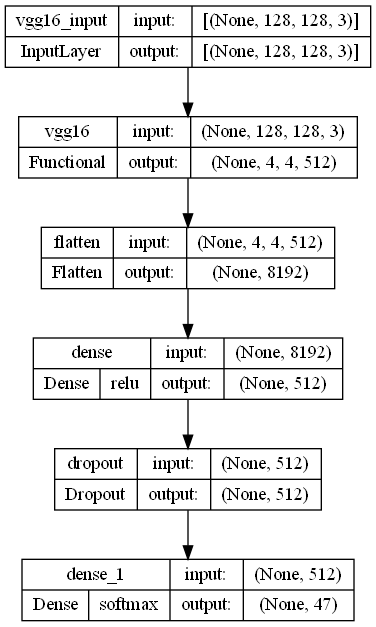

In [15]:
plot_model(global_model, to_file='inception_model.png', show_shapes=True, show_layer_activations=True, show_dtype=False, show_layer_names=True)

### **Federated Training**

In [16]:
%%time

# Federated learning loop
for epoch in range(NUM_EPOCHS):
    print(f'[EPOCH #{epoch+1}] ------------------------ running epochs {epoch+1}')
    # Create a copy of the global model for each client
    client_models = []
    for i in range(NUM_CLIENTS):
        client_model = create_vgg16_model(f"CLIENT[{i+1}]")
        client_model.set_weights(global_model.get_weights())
        client_models.append(client_model)
    
    # Train each client model on its own data
    for i in range(NUM_CLIENTS):
        # 

        print(f'[CLIENT #{i+1}] ....................... training begins...')
        start = i * (len(x_train) // NUM_CLIENTS)
        end = (i+1) * (len(x_train) // NUM_CLIENTS)
        if DEBUG is True:
          print(f"[DEBUG] ################################## Client[{i+1}] - Training on x_train[{start}]:x_train[{end}]")
        x_train_i = x_train[start:end]
        y_train_i = y_train[start:end]
        client_models[i].fit(x_train_i, y_train_i, batch_size=BATCH_SIZE, epochs=1, verbose=1)
    
    # Average the weights of the client models to update the global model
    average_weights = []
    global_weights = global_model.get_weights()
    for j in range(len(global_weights)):
        layer_weights = np.array([client_models[i].get_weights()[j] for i in range(NUM_CLIENTS)])
        average_layer_weights = np.mean(layer_weights, axis=0)
    
        # Calculate the proximal update term by subtracting the global weights from the average layer weights
        proximal_update = (average_layer_weights - global_weights[j]) * proximal_coefficient
    
        # Update the global weights with the proximal term
        updated_layer_weights = global_weights[j] + proximal_update
        average_weights.append(updated_layer_weights)

    global_model.set_weights(average_weights)
    
    # Evaluate the global model
    loss, acc = global_model.evaluate(x_test, y_test, verbose=0)
    global_acc_list.append(acc)
    global_loss_list.append(loss)
    print('[SUMMARY] ------------------------ Epoch #{}, Global Test Loss: {}, Global Test Accuracy: {}\n'.format(epoch+1, loss, acc))

[EPOCH #1] ------------------------ running epochs 1
........................ creating VGG16 model : CLIENT[1]
........................ creating VGG16 model : CLIENT[2]
........................ creating VGG16 model : CLIENT[3]
[CLIENT #1] ....................... training begins...
196/196 [==============================] - 439s 2s/step - loss: 2.4859 - accuracy: 0.3341
[CLIENT #2] ....................... training begins...
196/196 [==============================] - 505s 3s/step - loss: 2.5323 - accuracy: 0.3182
[CLIENT #3] ....................... training begins...
196/196 [==============================] - 375s 2s/step - loss: 2.6049 - accuracy: 0.2957
[SUMMARY] ------------------------ Epoch #1, Global Test Loss: 3.3014566898345947, Global Test Accuracy: 0.3390425443649292

[EPOCH #2] ------------------------ running epochs 2
........................ creating VGG16 model : CLIENT[1]
........................ creating VGG16 model : CLIENT[2]
........................ creating VGG16 mode

In [17]:
global_model.save('vgg16-e10.h5')

C:\Users\USER\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#### Metrics

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Train set
y_train_pred = global_model.predict(x_train)
y_train_pred = np.argmax(y_train_pred, axis=1)
y_train_true = np.argmax(y_train, axis=1)

# Test set
y_pred = global_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Metrix
cm = confusion_matrix(y_true, y_pred)
cm_train = confusion_matrix(y_train_true, y_train_pred)

294/294 [==============================] - 329s 1s/step


In [19]:
import re
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, digits=4)
print('test metrics: ')
print(report)

accuracy = float(re.findall(r'accuracy\s+([\d.]+)', report)[0])
precision = float(re.findall(r'weighted avg\s+([\d.]+)', report)[0])
recall = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)', report)[0][1])
f1_score = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', report)[0][2])

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")

report = classification_report(y_train_true, y_train_pred, digits=4)
print('-----------------------')
print('train metrics: ')
print(report)

accuracy_train = float(re.findall(r'accuracy\s+([\d.]+)', report)[0])
precision_train = float(re.findall(r'weighted avg\s+([\d.]+)', report)[0])
recall_train = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)', report)[0][1])
f1_score_train = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', report)[0][2])

print(f"Accuracy: {accuracy_train:.2%}")
print(f"Precision: {precision_train:.2%}")
print(f"Recall: {recall_train:.2%}")
print(f"F1-score: {f1_score_train:.2%}")


test metrics: 
              precision    recall  f1-score   support

           0     0.9751    0.9703    0.9727       202
           1     0.8722    0.9340    0.9021       212
           2     1.0000    0.9847    0.9923       196
           3     1.0000    1.0000    1.0000       201
           4     1.0000    0.9754    0.9875       203
           5     0.9317    0.9095    0.9205       210
           6     0.9950    0.9950    0.9950       201
           7     0.9944    0.9944    0.9944       180
           8     0.9850    0.9949    0.9899       198
           9     0.9706    0.9900    0.9802       200
          10     0.9954    0.9864    0.9909       220
          11     0.9953    0.9861    0.9907       216
          12     0.9632    0.9683    0.9657       189
          13     0.9951    1.0000    0.9975       203
          14     0.9945    1.0000    0.9973       182
          15     0.9858    1.0000    0.9928       208
          16     0.9848    1.0000    0.9923       194
          17

#### Visualization

In [20]:
print('For Graph Plotting\n')
print('Total EPOCHs : ', len(global_acc_list))
print('Total Clients : ', NUM_CLIENTS)
print('Global Loss list : ',global_loss_list)
print('Global Acc list : ',global_acc_list)

For Graph Plotting

Total EPOCHs :  30
Total Clients :  3
Global Loss list :  [3.3014566898345947, 2.0900020599365234, 1.254462718963623, 0.841222882270813, 0.5922697186470032, 0.4626413881778717, 0.38014915585517883, 0.3211729824542999, 0.27455198764801025, 0.2481546849012375, 0.2201845794916153, 0.18629775941371918, 0.17003346979618073, 0.15428121387958527, 0.15275134146213531, 0.14582131803035736, 0.14007270336151123, 0.141318678855896, 0.1295708566904068, 0.12303783744573593, 0.11711104959249496, 0.10595721006393433, 0.10190211236476898, 0.09806881844997406, 0.09373141080141068, 0.08948926627635956, 0.0903734341263771, 0.09595471620559692, 0.0940435454249382, 0.08911444246768951]
Global Acc list :  [0.3390425443649292, 0.7208510637283325, 0.8212766051292419, 0.8585106134414673, 0.8878723382949829, 0.909361720085144, 0.9247872233390808, 0.9359574317932129, 0.9440425634384155, 0.949042558670044, 0.9524468183517456, 0.9553191661834717, 0.957446813583374, 0.9609574675559998, 0.96329784

Total EPOCHs :  30
Total Clients :  3


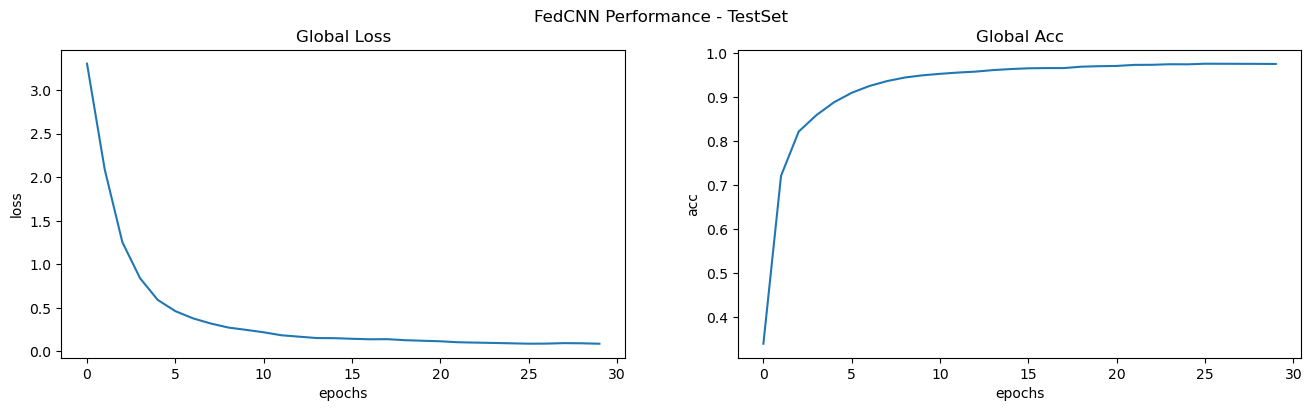

In [21]:
plt.figure(figsize=(16,4))
plt.suptitle("FedCNN Performance - TestSet")
plt.subplot(121)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.plot(list(range(0,len(global_loss_list))), global_loss_list)
plt.title("Global Loss")

plt.subplot(122)
plt.xlabel("epochs")
plt.ylabel("acc")
plt.plot(list(range(0,len(global_acc_list))), global_acc_list)
plt.title("Global Acc")

print('Total EPOCHs : ', len(global_acc_list))
print('Total Clients : ', NUM_CLIENTS)

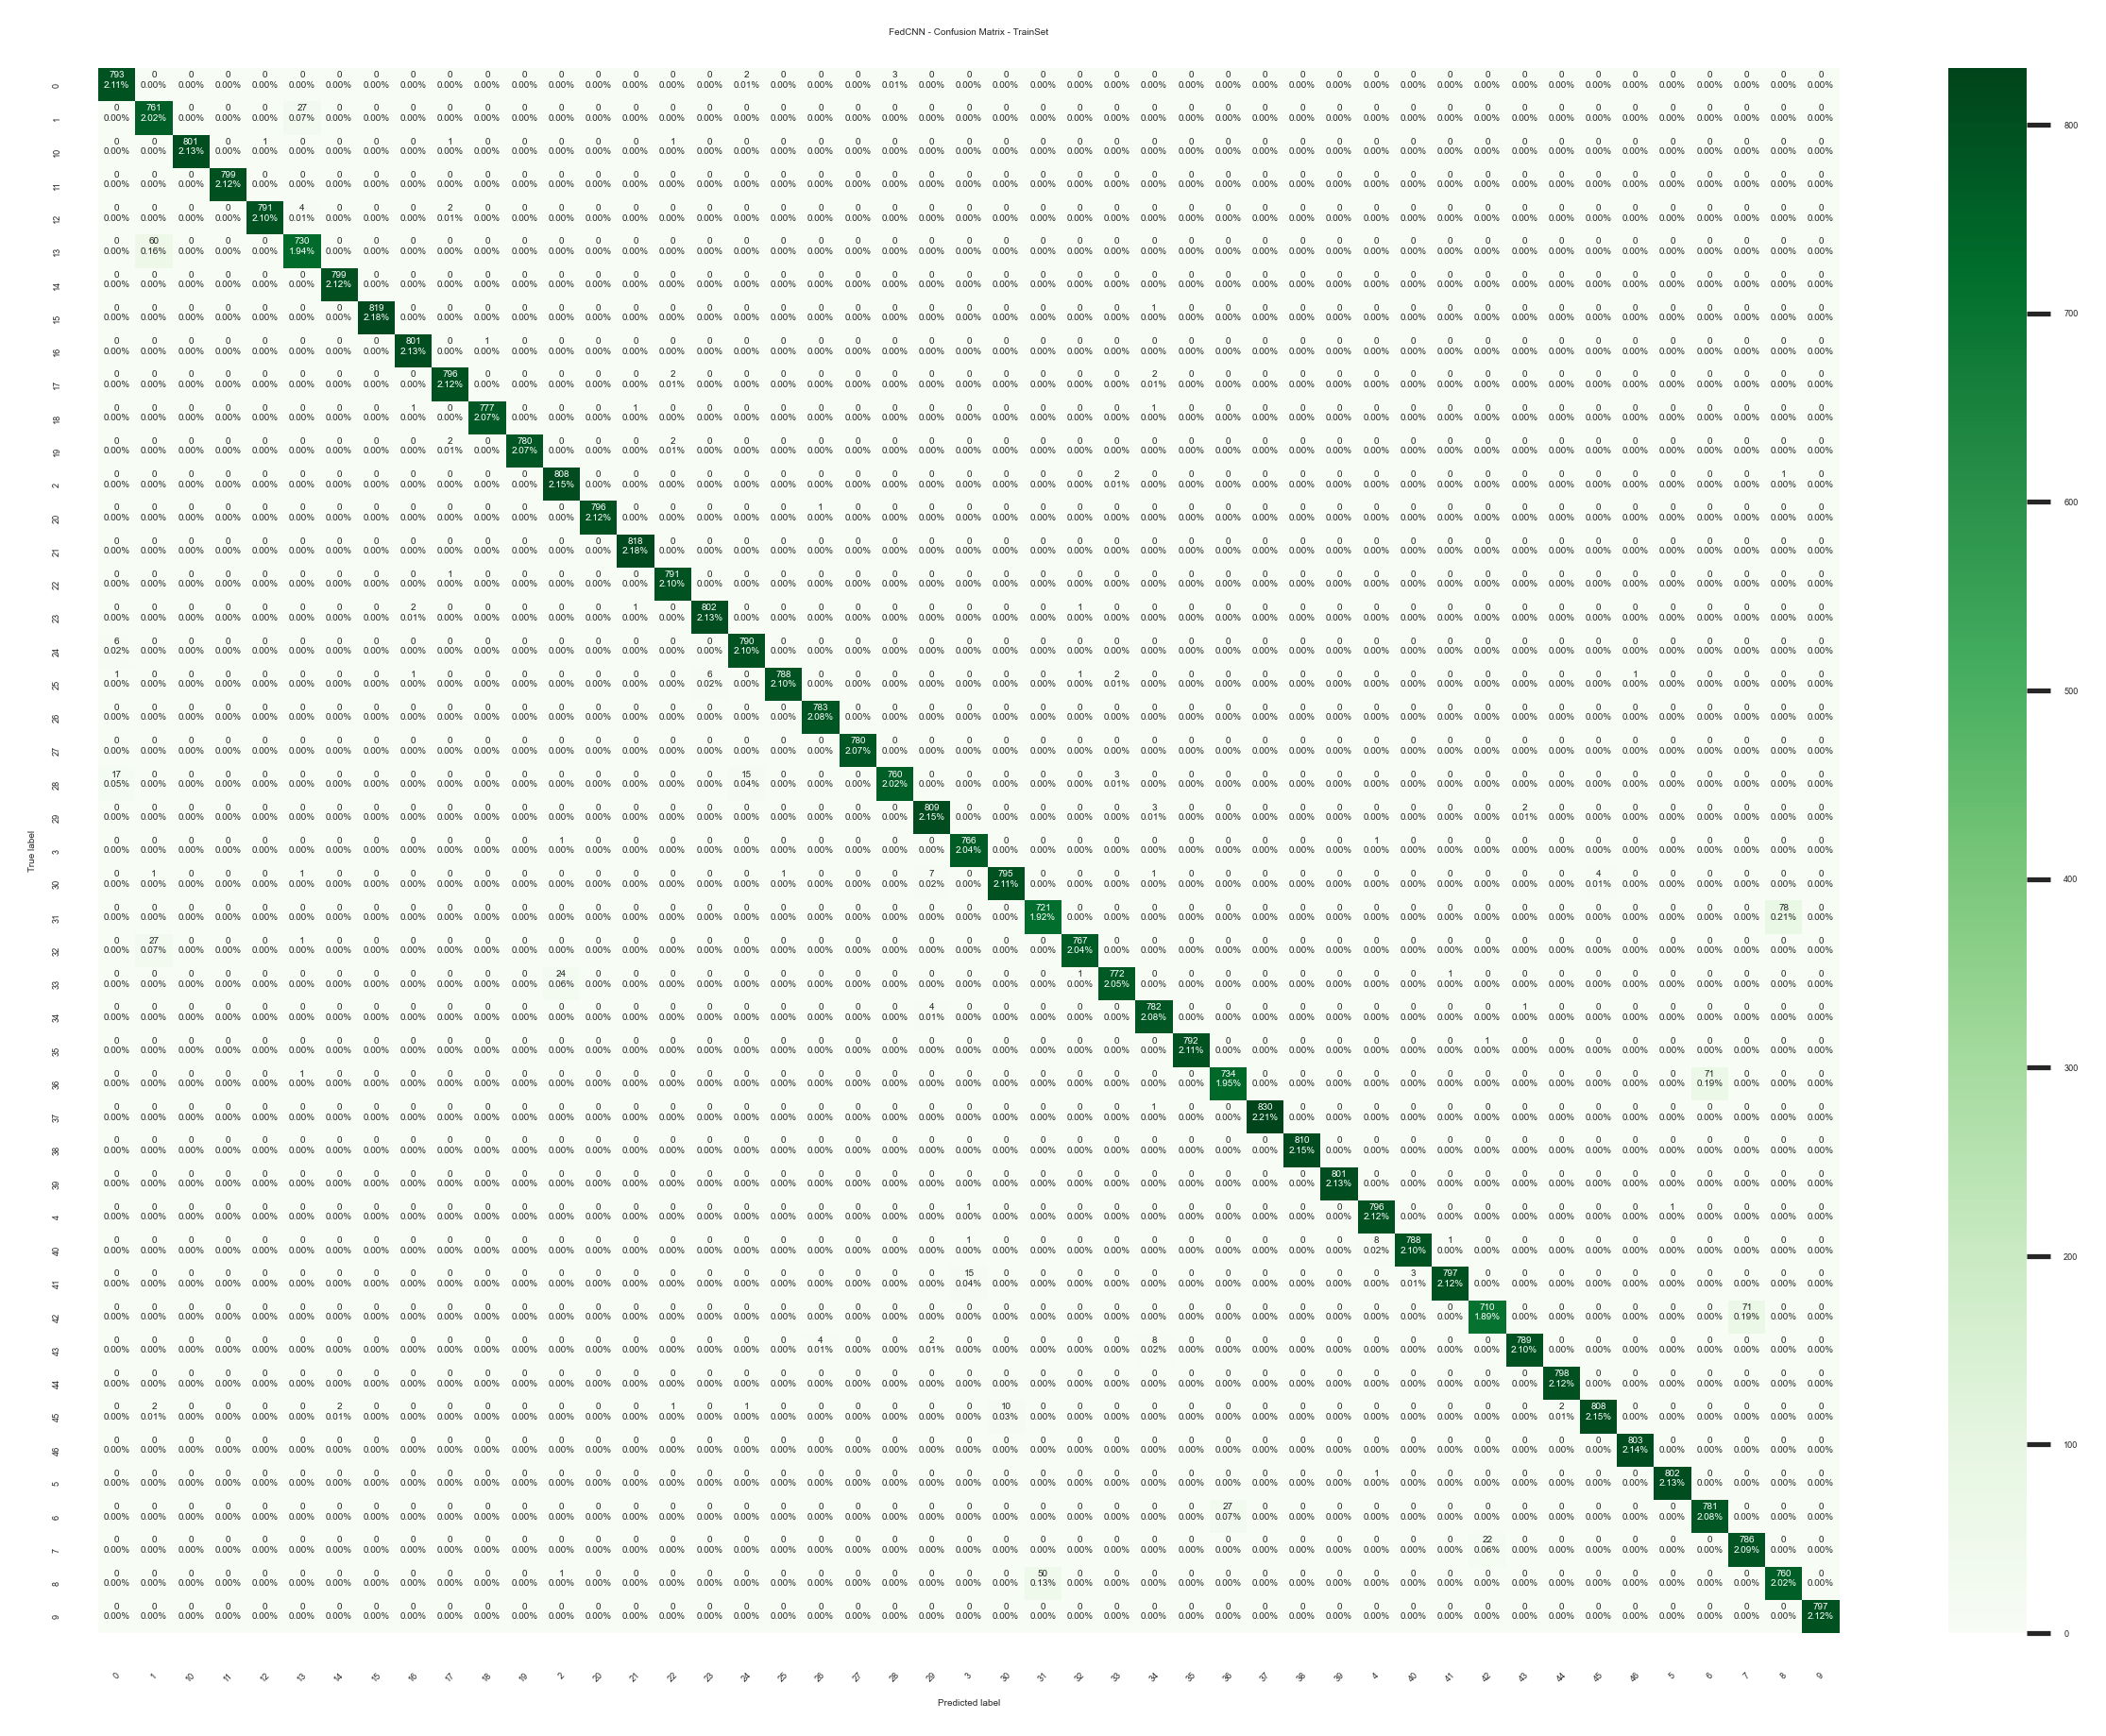

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn Heatmap - Train Set
group_counts = ["{0:0.0f}".format(value) for value in cm_train.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm_train.flatten()/np.sum(cm_train)]
labels = [f"{v1}\n{v2}\n" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cm_train.shape[0],cm_train.shape[1])
# stats_text = "\n\nAccuracy={:0.5f}\nPrecision={:0.5f}\nRecall={:0.5f}\nF1 Score={:0.5f}".format(accuracy_train, precision_train, recall_train, f1_score_train)
plt.figure(figsize=(8,6), dpi=300)
sns.set(font_scale=.2)
ax = sns.heatmap(cm_train, annot=labels, fmt='' ,xticklabels=class_names, yticklabels=class_names, cmap="Greens")
ax.tick_params(axis='x', labelrotation=45) # rotate x-axis tick labels by 45 degrees
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("FedCNN - Confusion Matrix - TrainSet\n")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_train.pdf", dpi=300, bbox_inches='tight')
plt.show()


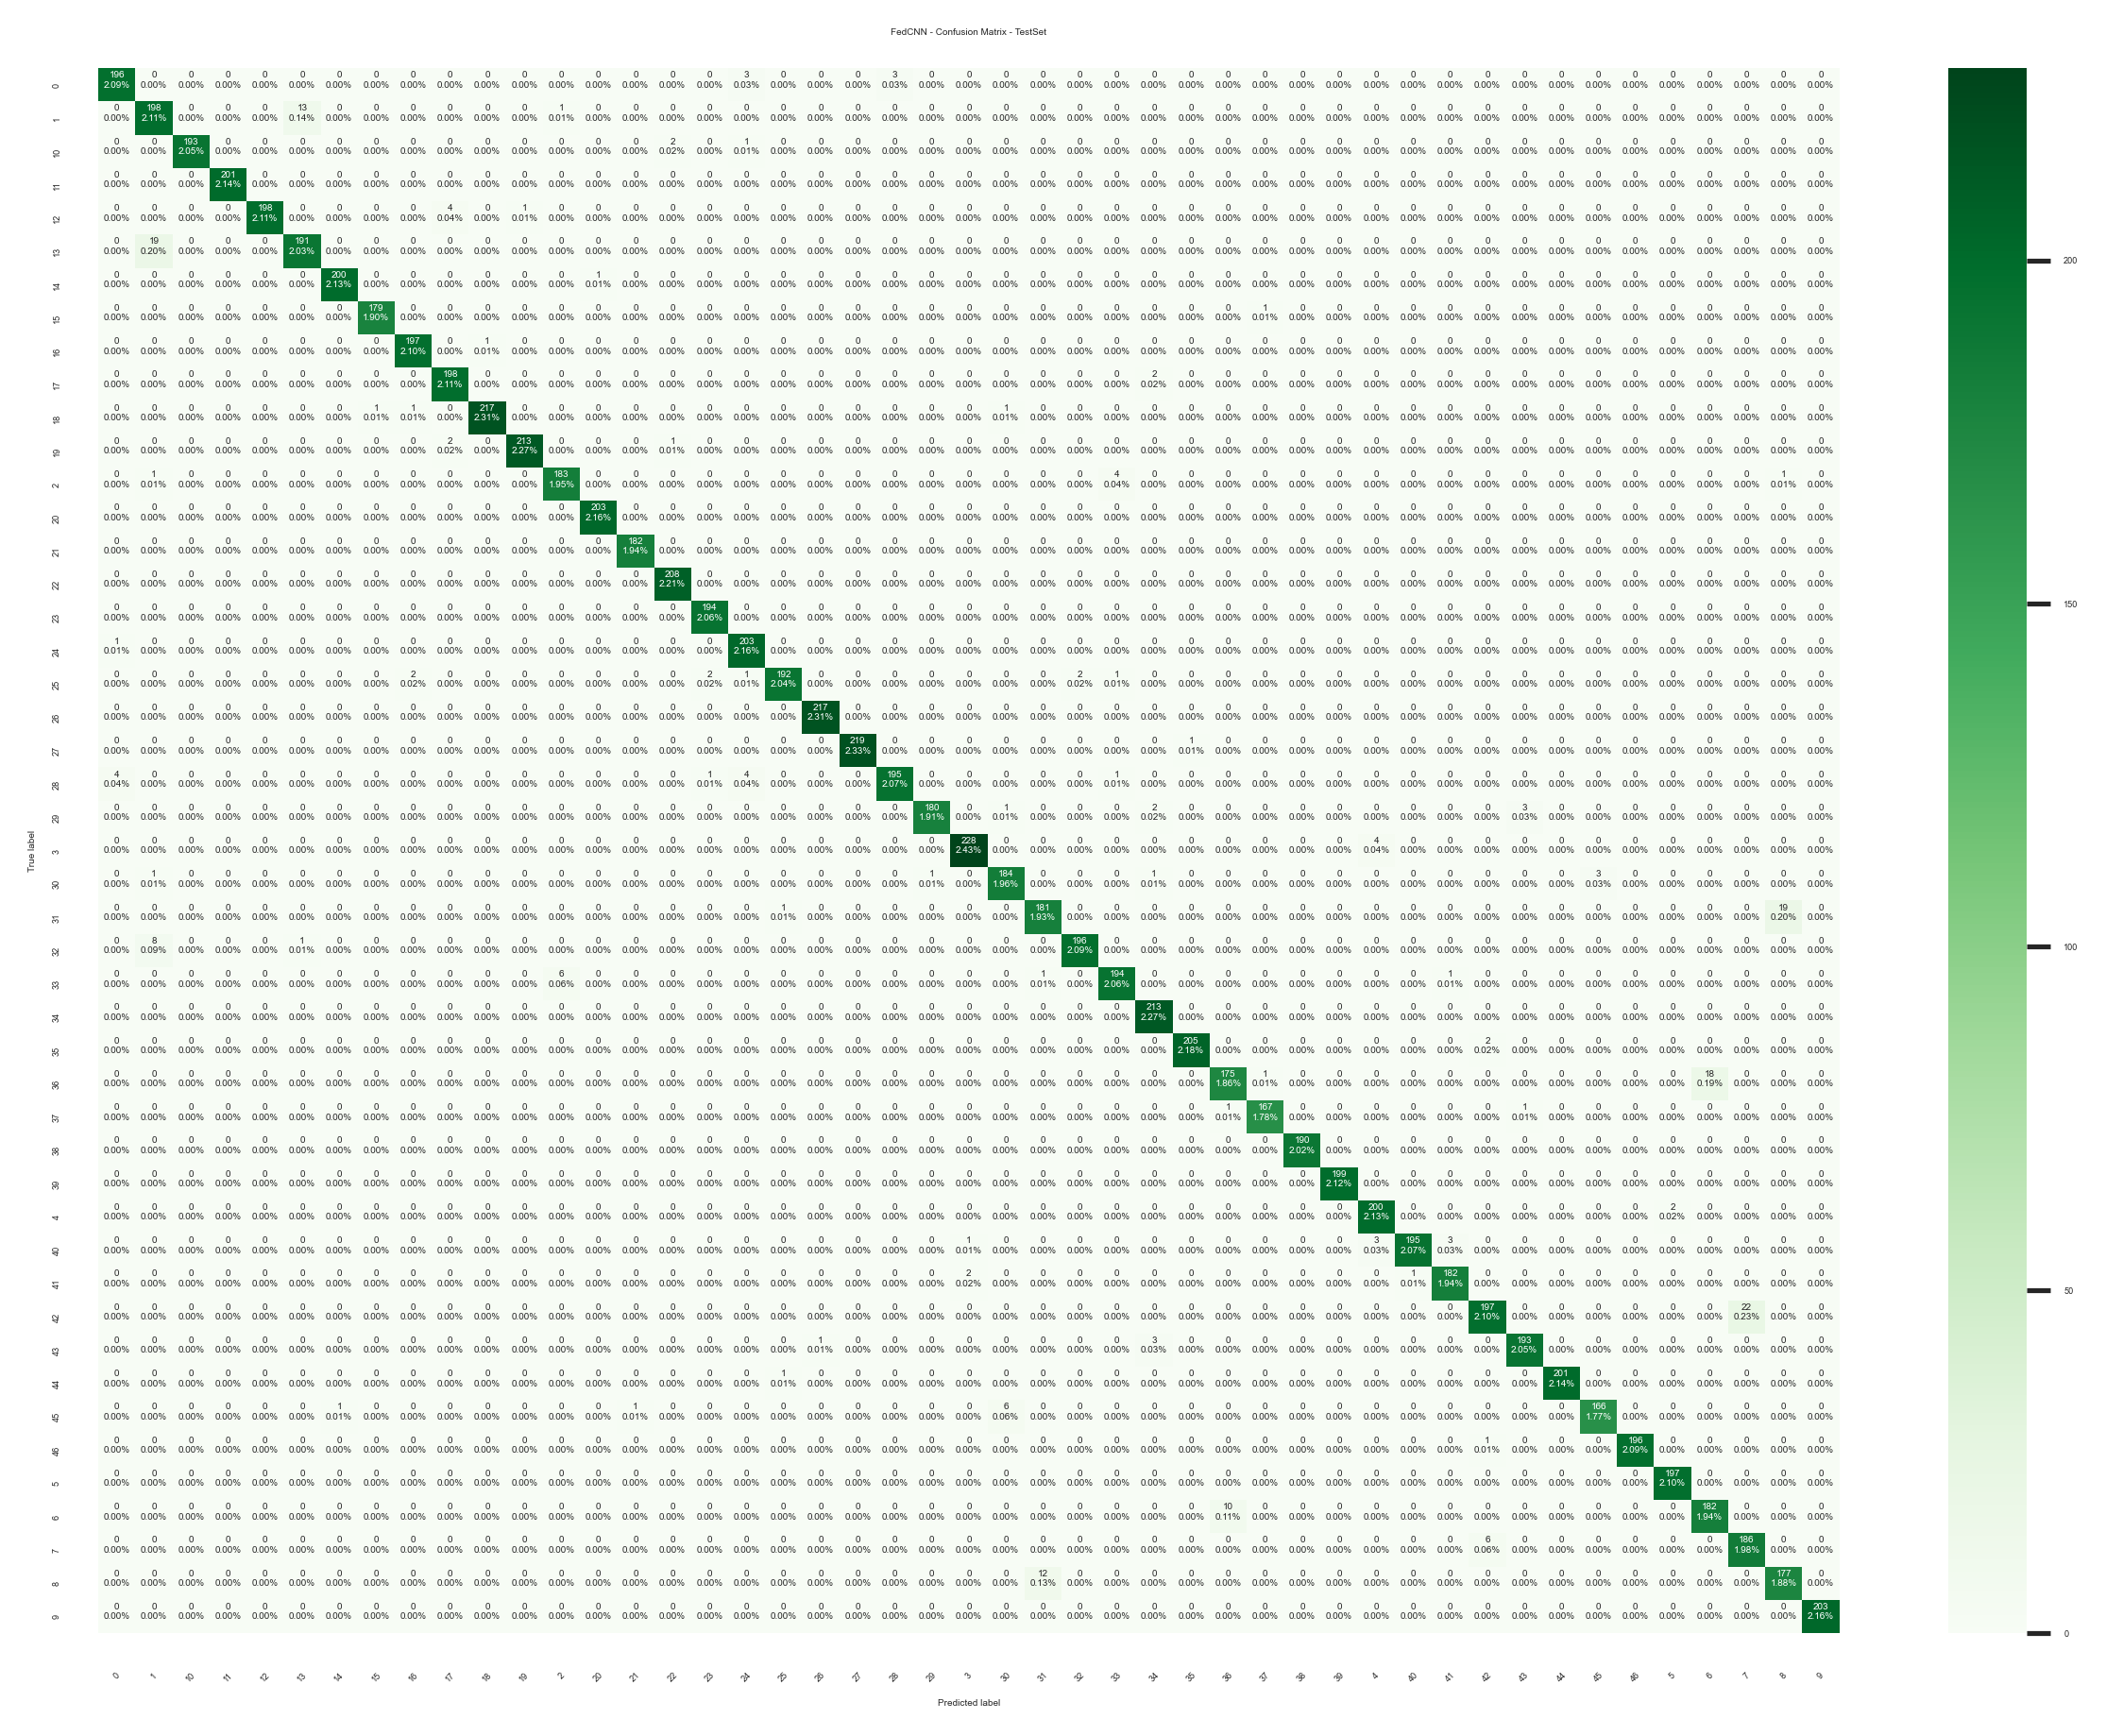

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn Heatmap - Test Set
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cm.shape[0],cm.shape[1])
# stats_text = "\n\nAccuracy={:0.5f}\nPrecision={:0.5f}\nRecall={:0.5f}\nF1 Score={:0.5f}".format(accuracy, precision, recall, f1_score)
plt.figure(figsize=(8,6), dpi=300)
sns.set(font_scale=.2)
ax = sns.heatmap(cm, annot=labels, fmt='' ,xticklabels=class_names, yticklabels=class_names, cmap="Greens")
ax.tick_params(axis='x', labelrotation=45) # rotate x-axis tick labels by 45 degrees
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("FedCNN - Confusion Matrix - TestSet\n")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_test.pdf", dpi=300, bbox_inches='tight')
plt.show()
